In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from scipy.stats import kendalltau, spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
PROJECT_DIR = Path(
    r"C:\Users\aleks\Documents\GitHub\asymmetric-catalysis-qspr-ml\regressor_II\substrate\no_chemberta_rev_1"
)

#TEST_DATA_FILE = PROJECT_DIR / (
    #r"Results\Selected_Data\RS42_consensus_n7_fast_aggr_False_test_data.parquet"
#)

TEST_DATA_FILE = PROJECT_DIR / (
    r"Data\molecular_descriptors_cleaned_exp_set_.parquet"
)

MODEL_FILE = PROJECT_DIR / (
    r"Results\Trained_Models\RS42_consensus_n8_cv_safe_False_GradientBoosting_model.pkl"
)

OUTPUT_DIR = PROJECT_DIR / "Results" / "ReviewerValidation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Test data:", TEST_DATA_FILE)
print("Model:", MODEL_FILE)
print("Output:", OUTPUT_DIR)

Test data: C:\Users\aleks\Documents\GitHub\asymmetric-catalysis-qspr-ml\regressor_II\substrate\no_chemberta_rev_1\Data\molecular_descriptors_cleaned_exp_set_.parquet
Model: C:\Users\aleks\Documents\GitHub\asymmetric-catalysis-qspr-ml\regressor_II\substrate\no_chemberta_rev_1\Results\Trained_Models\RS42_consensus_n8_cv_safe_False_GradientBoosting_model.pkl
Output: C:\Users\aleks\Documents\GitHub\asymmetric-catalysis-qspr-ml\regressor_II\substrate\no_chemberta_rev_1\Results\ReviewerValidation


In [3]:
assert TEST_DATA_FILE.exists(), f"Nie znaleziono: {TEST_DATA_FILE}"
assert MODEL_FILE.exists(), f"Nie znaleziono: {MODEL_FILE}"

print("OK — files found.")

OK — files found.


In [4]:
test_df = pd.read_parquet(TEST_DATA_FILE)
final_model = joblib.load(MODEL_FILE)

print("Test set shape:", test_df.shape)
display(test_df.head())

Test set shape: (12, 4073)


,AATS0Z,AATS0are,AATS0d,AATS0dv,AATS0i,AATS0m,AATS0p,AATS0pe,AATS0s,AATS0se,...,ChyLine_l2-4_CF,ChyLine_l2-4_Cc:cC,ChyLine_l2-4_cOC,ChyLine_l2-4_c:cOC,ChyLine_l2-4_c:c:cF,ChyLine_l2-4_cF,ChyLine_l2-4_c:cF,ChyLine_l2-4_CC=Cc,ChyLine_l2-4_C=CCC,ee
0,59.812500,5.903987,3.281250,6.845850,152.639084,284.572378,1.973030,6.064303,4.063210,7.476328,...,0,0,0,0,0,0,0,0,0,92
1,65.714286,5.955271,3.321429,7.109543,152.179524,314.848419,2.023927,6.120454,4.151605,7.525876,...,0,0,0,0,0,0,0,0,0,89
2,65.714286,5.955271,3.321429,7.109543,152.179524,314.848419,2.023927,6.120454,4.151605,7.525876,...,0,0,0,0,0,0,0,0,0,11
3,53.384615,6.129169,3.153846,7.411980,156.969698,250.425141,1.768993,6.245831,3.982064,7.701546,...,0,0,0,0,0,0,0,0,0,87
4,26.243902,6.396949,3.536585,9.853659,155.841255,104.020867,1.683388,6.481183,6.553523,7.871617,...,0,0,0,0,0,0,0,0,0,90


In [5]:
test_df

,AATS0Z,AATS0are,AATS0d,AATS0dv,AATS0i,AATS0m,AATS0p,AATS0pe,AATS0s,AATS0se,...,ChyLine_l2-4_CF,ChyLine_l2-4_Cc:cC,ChyLine_l2-4_cOC,ChyLine_l2-4_c:cOC,ChyLine_l2-4_c:c:cF,ChyLine_l2-4_cF,ChyLine_l2-4_c:cF,ChyLine_l2-4_CC=Cc,ChyLine_l2-4_C=CCC,ee
0,59.812500,5.903987,3.281250,6.845850,152.639084,284.572378,1.973030,6.064303,4.063210,7.476328,...,0,0,0,0,0,0,0,0,0,92
1,65.714286,5.955271,3.321429,7.109543,152.179524,314.848419,2.023927,6.120454,4.151605,7.525876,...,0,0,0,0,0,0,0,0,0,89
2,65.714286,5.955271,3.321429,7.109543,152.179524,314.848419,2.023927,6.120454,4.151605,7.525876,...,0,0,0,0,0,0,0,0,0,11
3,53.384615,6.129169,3.153846,7.411980,156.969698,250.425141,1.768993,6.245831,3.982064,7.701546,...,0,0,0,0,0,0,0,0,0,87
4,26.243902,6.396949,3.536585,9.853659,155.841255,104.020867,1.683388,6.481183,6.553523,7.871617,...,0,0,0,0,0,0,0,0,0,90
5,22.476190,6.116307,3.119048,7.666667,159.288621,88.676752,1.537532,6.196426,5.945106,7.647081,...,0,0,0,0,0,0,0,0,0,91
6,60.580645,5.892826,3.258065,6.679588,153.472785,289.098451,1.946712,6.050168,3.903959,7.474257,...,0,0,0,0,0,0,0,0,0,94
7,28.838710,6.965161,3.580645,11.677419,166.416679,118.006084,1.647971,6.988219,9.957213,8.254938,...,3,1,0,0,0,0,0,0,0,72
8,22.437500,6.008125,3.125000,7.375000,155.889356,88.574589,1.629168,6.108350,4.198785,7.544068,...,0,0,1,2,0,0,0,0,0,99
9,23.677419,6.192903,3.258065,8.258065,158.762723,94.785229,1.656639,6.278516,5.931900,7.656129,...,0,0,0,0,2,1,2,0,0,98


In [6]:
TARGET_COLUMN = "ee"

In [7]:
display(test_df[[TARGET_COLUMN]].head(10))
assert test_df[TARGET_COLUMN].notna().all(), ()

,ee
0,92
1,89
2,11
3,87
4,90
5,91
6,94
7,72
8,99
9,98


In [8]:
import joblib
print(final_model.named_steps.keys())


imputer = final_model.named_steps["imputer"]


FEATURE_COLUMNS_MODEL = list(imputer.feature_names_in_)


print("Number of features:", len(FEATURE_COLUMNS_MODEL))
#print("number of features test_df:", len(FEATURE_COLUMNS))
print(FEATURE_COLUMNS_MODEL)

dict_keys(['imputer', 'scaler', 'model'])
Number of features: 8
['ATS5s', 'ATS3i', 'AMID_C', 'AATSC4i', 'nRot', 'Sterimol_Beta_R1_B5', 'ATSC7Z', 'GATS3d']


In [9]:
FEATURE_COLUMNS = [
                               'ATS5s', 'ATS3i', 'AMID_C', 'AATSC4i', 'nRot', 'Sterimol_Beta_R1_B5', 'ATSC7Z', 'GATS3d'
]



In [10]:
missing_features = [
    feature for feature in FEATURE_COLUMNS
    if feature not in test_df.columns
]

assert not missing_features, (
    f"Not found: {missing_features}"
)

In [11]:
# Podejrzyj kroki pipeline
print(final_model.named_steps.keys())

# Zwykle pierwszy krok, np. "imputer"
imputer = final_model.named_steps["imputer"]

# Kolejność cech zapamiętana podczas fit()
FEATURE_COLUMNS_MODEL = list(imputer.feature_names_in_)

# Diagnostyka
print("Liczba cech oczekiwana przez model:", len(FEATURE_COLUMNS_MODEL))
print("Liczba cech w test_df:", len(FEATURE_COLUMNS))
print(FEATURE_COLUMNS_MODEL)

dict_keys(['imputer', 'scaler', 'model'])
Liczba cech oczekiwana przez model: 8
Liczba cech w test_df: 8
['ATS5s', 'ATS3i', 'AMID_C', 'AATSC4i', 'nRot', 'Sterimol_Beta_R1_B5', 'ATSC7Z', 'GATS3d']


In [12]:
X_test = test_df[FEATURE_COLUMNS].copy()
y_true = test_df[TARGET_COLUMN].to_numpy(dtype=float)

y_pred = final_model.predict(X_test)

prospective_predictions = pd.DataFrame({
    "test_index": test_df.index.astype(str),
    "observed_ee": y_true,
    "final_model_prediction": y_pred,
})

display(prospective_predictions.round(2))

,test_index,observed_ee,final_model_prediction
0,0,92.0,81.53
1,1,89.0,82.79
2,2,11.0,42.70
3,3,87.0,63.67
4,4,90.0,78.25
5,5,91.0,78.25
6,6,94.0,89.64
7,7,72.0,72.91
8,8,99.0,62.42
9,9,98.0,90.94


In [13]:
#def calculate_metrics(y_true, y_pred):
 #   rho_result = spearmanr(y_true, y_pred)
 #   tau_result = kendalltau(y_true, y_pred)

  #  return {
   #     "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
   #     "MAE": mean_absolute_error(y_true, y_pred),
   #     "Spearman_rho": rho_result.statistic,
    #    "Kendall_tau": tau_result.statistic,
   # }

def calculate_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    if np.unique(y_true).size < 2 or np.unique(y_pred).size < 2:
        spearman_rho = np.nan
        kendall_tau = np.nan
    else:
        spearman_rho = spearmanr(y_true, y_pred).statistic
        kendall_tau = kendalltau(y_true, y_pred).statistic

    return {
        "RMSE": rmse,
        "MAE": mae,
        "Spearman_rho": spearman_rho,
        "Kendall_tau": kendall_tau,
    }

In [14]:
point_metrics = calculate_metrics(y_true, y_pred)

point_metrics_table = pd.DataFrame([point_metrics])
display(point_metrics_table.round(3))

,RMSE,MAE,Spearman_rho,Kendall_tau
0,26.199,18.835,0.523,0.431


In [15]:
N_BOOTSTRAP = 10_000
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)

n_test = len(y_true)
bootstrap_rows = []

for iteration in range(1, N_BOOTSTRAP + 1):
    sampled_indices = rng.integers(
        low=0,
        high=n_test,
        size=n_test,
    )

    y_true_sample = y_true[sampled_indices]
    y_pred_sample = y_pred[sampled_indices]

    metrics = calculate_metrics(y_true_sample, y_pred_sample)

    bootstrap_rows.append({
        "bootstrap_iteration": iteration,
        **metrics,
    })

bootstrap_metrics_raw = pd.DataFrame(bootstrap_rows)

display(bootstrap_metrics_raw.head())

,bootstrap_iteration,RMSE,MAE,Spearman_rho,Kendall_tau
0,1,25.305796,17.136402,0.481284,0.373996
1,2,27.369720,19.942186,0.224201,0.227650
2,3,23.145556,14.811384,0.902322,0.790425
3,4,31.538500,22.114207,0.438163,0.349206
4,5,21.889982,17.821220,-0.025135,0.050007


In [16]:
bootstrap_metrics_raw.to_excel("epox_II_bootstrap.xlsx")

In [17]:
summary_rows = []

for metric_name in [
    "RMSE",
    "MAE",
    "Spearman_rho",
    "Kendall_tau",
]:
    metric_values = bootstrap_metrics_raw[metric_name].dropna()

    summary_rows.append({
        "metric": metric_name,
        "point_estimate": point_metrics[metric_name],
        "bootstrap_median": metric_values.median(),
        "bootstrap_ci95_lower": metric_values.quantile(0.025),
        "bootstrap_ci95_upper": metric_values.quantile(0.975),
        "n_valid_bootstrap": len(metric_values),
        "n_total_bootstrap": N_BOOTSTRAP,
    })

bootstrap_metrics_summary = pd.DataFrame(summary_rows)

display(bootstrap_metrics_summary.round(3))

,metric,point_estimate,bootstrap_median,bootstrap_ci95_lower,bootstrap_ci95_upper,n_valid_bootstrap,n_total_bootstrap
0,RMSE,26.199,25.401,12.484,38.502,10000,10000
1,MAE,18.835,18.380,9.917,30.047,10000,10000
2,Spearman_rho,0.523,0.507,-0.159,0.937,10000,10000
3,Kendall_tau,0.431,0.436,-0.082,0.850,10000,10000


In [18]:
bootstrap_metrics_summary.to_excel('bootstrap_exp_set.xlsx')

Saved SVG: C:\Users\aleks\Documents\GitHub\asymmetric-catalysis-qspr-ml\regressor_II\substrate\no_chemberta_rev_1\QSPR\bootstrap_prospective_epox_II.svg


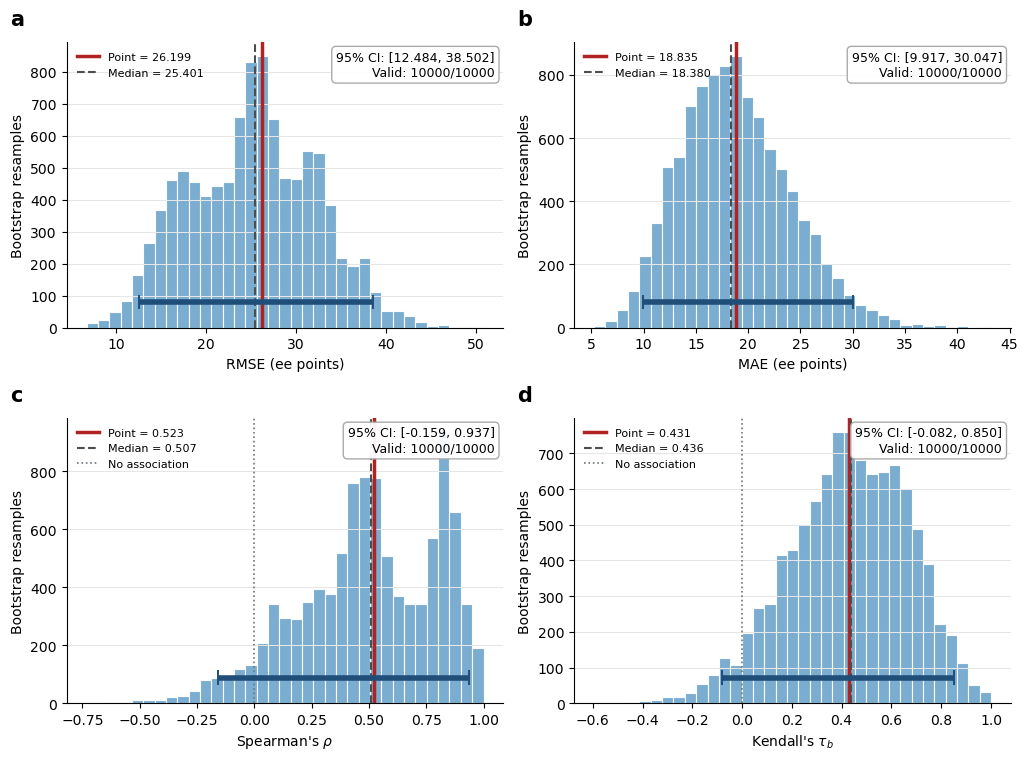

In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

OUTPUT_FILE = Path("bootstrap_prospective_epox_II.svg")

COLORS = {
    "histogram": "#74A9CF",
    "point": "#B22222",
    "median": "#4D4D4D",
    "ci": "#1F4E79",
    "zero": "#6C757D",
    "grid": "#E6E6E6",
}

metrics_config = [
    ("RMSE", "RMSE (ee points)", "a"),
    ("MAE", "MAE (ee points)", "b"),
    ("Spearman_rho", r"Spearman's $\rho$", "c"),
    ("Kendall_tau", r"Kendall's $\tau_b$", "d"),
]

summary_lookup = bootstrap_metrics_summary.set_index("metric")

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10.3, 7.7),
)

for ax, (metric, xlabel, panel) in zip(
    axes.ravel(),
    metrics_config,
):
    values = pd.to_numeric(
        bootstrap_metrics_raw[metric],
        errors="coerce",
    ).dropna()

    summary = summary_lookup.loc[metric]

    point_estimate = float(summary["point_estimate"])
    median = float(summary["bootstrap_median"])
    ci_low = float(summary["bootstrap_ci95_lower"])
    ci_high = float(summary["bootstrap_ci95_upper"])
    n_valid = int(summary["n_valid_bootstrap"])
    n_total = int(summary["n_total_bootstrap"])

    ax.hist(
        values,
        bins=35,
        color=COLORS["histogram"],
        edgecolor="white",
        linewidth=0.8,
        alpha=0.95,
    )

    ax.axvline(
        point_estimate,
        color=COLORS["point"],
        linewidth=2.5,
        label=f"Point = {point_estimate:.3f}",
    )

    ax.axvline(
        median,
        color=COLORS["median"],
        linestyle="--",
        linewidth=1.5,
        label=f"Median = {median:.3f}",
    )

    if metric in {"Spearman_rho", "Kendall_tau"}:
        ax.axvline(
            0,
            color=COLORS["zero"],
            linestyle=":",
            linewidth=1.2,
            label="No association",
        )

    ymax = ax.get_ylim()[1]
    y_ci = ymax * 0.09

    ax.hlines(
        y_ci,
        ci_low,
        ci_high,
        color=COLORS["ci"],
        linewidth=4,
    )

    ax.vlines(
        [ci_low, ci_high],
        y_ci * 0.72,
        y_ci * 1.28,
        color=COLORS["ci"],
        linewidth=1.4,
    )

    ax.text(
        -0.13,
        1.06,
        panel,
        transform=ax.transAxes,
        fontsize=15,
        fontweight="bold",
    )

    ax.text(
        0.98,
        0.97,
        (
            f"95% CI: [{ci_low:.3f}, {ci_high:.3f}]\n"
            f"Valid: {n_valid}/{n_total}"
        ),
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="#A6A6A6",
            alpha=0.95,
        ),
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Bootstrap resamples")

    ax.yaxis.grid(
        True,
        color=COLORS["grid"],
        linewidth=0.75,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        frameon=False,
        fontsize=8,
        loc="upper left",
    )

fig.tight_layout()

# Save the existing figure as SVG before displaying it.
fig.savefig(
    OUTPUT_FILE,
    format="svg",
    bbox_inches="tight",
    facecolor="white",
)

print(f"Saved SVG: {OUTPUT_FILE.resolve()}")

plt.show()